<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_01_what_is_rl/01_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 — Exercises
## What Is Reinforcement Learning?

**Instructions:** Complete each exercise cell. Solutions are in `01_exercises_solutions.ipynb`.

### Exercise 1.1: Add a new environment feature
The current GridWorld gives -5 for hitting a wall. Modify `GridWorld.step()` so that hitting a wall **teleports the agent back to (0,0)** instead of keeping it in place. Re-run the training and compare the learning curves.

*What do you expect will happen to the learning speed? Why?*

In [13]:
# Your implementation here
class GridWorldTeleport:
    pass

class GridWorldCautious(GridWorld):
    def __init__(self, height=5, width=5):
        super().__init__(height, width)
        self.reward_wall = -50  # Much higher penalty for hitting a wall

class GridWorldExplore(GridWorld):
    def __init__(self, height=5, width=5):
        super().__init__(height, width)
        self.visited_cells = set()
        self.exploration_reward = 0.5 # Small positive reward for visiting a new cell

    def reset(self):
        self.visited_cells = set()
        self.current_state = self.start_state
        self.visited_cells.add(self.current_state)
        return self.current_state

    def step(self, action):
        dr, dc = self.actions[action]
        next_row, next_col = self.current_state[0] + dr, self.current_state[1] + dc

        reward = self.reward_step
        done = False

        # Check for wall collision
        if not (0 <= next_row < self.height and 0 <= next_col < self.width):
            reward = self.reward_wall
            next_state = self.current_state # Agent stays in place
        else:
            next_state = (next_row, next_col)
            if next_state not in self.visited_cells:
                reward += self.exploration_reward # Add exploration reward for new cell
                self.visited_cells.add(next_state)

        self.current_state = next_state

        # Check for goal
        if next_state == self.goal_state:
            reward = self.reward_goal
            done = True

        return next_state, reward, done

class GridWorldDiagonal(GridWorld):
    def __init__(self, height=5, width=5):
        super().__init__(height, width)
        # Add diagonal actions
        # 0:up, 1:down, 2:left, 3:right, 4:up-left, 5:up-right, 6:down-left, 7:down-right
        self.actions = {
            0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1),
            4: (-1, -1), 5: (-1, 1), 6: (1, -1), 7: (1, 1)
        }

# Train and compare

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the base GridWorld class (assuming a typical setup)
class GridWorld:
    def __init__(self, height=5, width=5):
        self.height = height
        self.width = width
        self.start_state = (0, 0)
        self.goal_state = (height - 1, width - 1)
        self.current_state = self.start_state
        # Actions: 0:up, 1:down, 2:left, 3:right
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        # Default rewards
        self.reward_goal = 10
        self.reward_step = -1
        self.reward_wall = -5

    def reset(self):
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        # Get action delta
        dr, dc = self.actions[action]
        next_row, next_col = self.current_state[0] + dr, self.current_state[1] + dc

        reward = self.reward_step
        done = False

        # Check for wall collision
        if not (0 <= next_row < self.height and 0 <= next_col < self.width):
            reward = self.reward_wall
            next_state = self.current_state # Agent stays in place
        else:
            next_state = (next_row, next_col)

        self_current_state = next_state

        # Check for goal
        if next_state == self.goal_state:
            reward = self.reward_goal
            done = True

        self.current_state = next_state
        return next_state, reward, done

    def get_state_space_size(self):
        return self.height * self.width

    def get_action_space_size(self):
        return len(self.actions)

Now, let's implement the `GridWorldTeleport` by inheriting from `GridWorld` and overriding the `step` method to implement the teleportation logic.

In [2]:
class GridWorldTeleport(GridWorld):
    def step(self, action):
        dr, dc = self.actions[action]
        next_row, next_col = self.current_state[0] + dr, self.current_state[1] + dc

        reward = self.reward_step
        done = False

        # Check for wall collision - TELEPORTATION logic
        if not (0 <= next_row < self.height and 0 <= next_col < self.width):
            reward = self.reward_wall  # Still get a penalty for hitting a wall
            next_state = self.start_state # Teleport to (0,0)
        else:
            next_state = (next_row, next_col)

        self.current_state = next_state

        # Check for goal
        if next_state == self.goal_state:
            reward = self.reward_goal
            done = True

        return next_state, reward, done

Next, we'll define the Q-learning training function that will be used for both environments.

In [3]:
def q_learning_train(env, num_episodes=2000, learning_rate=0.1, discount_factor=0.99, epsilon=0.1):
    q_table = np.zeros((env.get_state_space_size(), env.get_action_space_size()))
    rewards_per_episode = []

    for episode in range(num_episodes):
        state = env.reset()
        state_idx = state[0] * env.width + state[1]
        done = False
        total_reward = 0

        while not done:
            # Epsilon-greedy action selection
            if np.random.uniform(0, 1) < epsilon:
                action = np.random.randint(env.get_action_space_size())  # Explore
            else:
                action = np.argmax(q_table[state_idx, :])  # Exploit

            next_state, reward, done = env.step(action)
            next_state_idx = next_state[0] * env.width + next_state[1]

            # Q-learning update rule
            q_table[state_idx, action] = q_table[state_idx, action] + learning_rate * \
                                        (reward + discount_factor * np.max(q_table[next_state_idx, :]) - q_table[state_idx, action])

            state = next_state
            state_idx = next_state_idx
            total_reward += reward

        rewards_per_episode.append(total_reward)
    return rewards_per_episode

Now, let's train agents in both the original and teleporting GridWorlds and compare their learning curves.

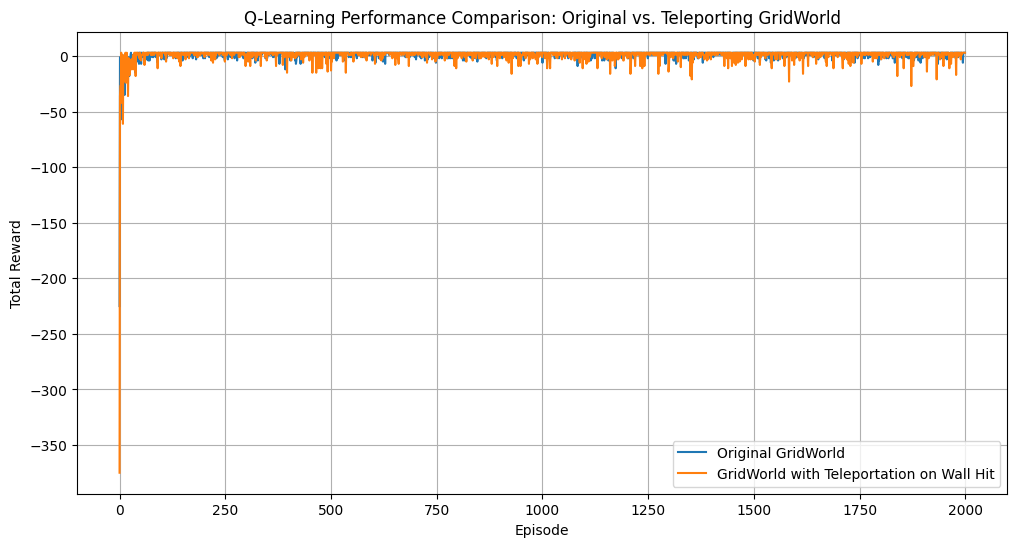

What do you expect will happen to the learning speed? Why?

Expected Outcome: I expect the learning speed to be slower for the teleporting environment. When the agent hits a wall in the original environment, it stays in place, allowing it to immediately try a different action from the same state. In the teleporting environment, hitting a wall sends the agent back to the start (0,0), which means it loses progress and has to relearn paths to the goal more frequently if it repeatedly hits walls. This added 'punishment' of losing progress will likely make the learning process less efficient, especially in the early stages where the agent is exploring randomly.


In [4]:
# Initialize environments
original_env = GridWorld()
teleport_env = GridWorldTeleport()

# Train agents
rewards_original = q_learning_train(original_env)
rewards_teleport = q_learning_train(teleport_env)

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards_original, label='Original GridWorld')
plt.plot(rewards_teleport, label='GridWorld with Teleportation on Wall Hit')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Performance Comparison: Original vs. Teleporting GridWorld')
plt.legend()
plt.grid(True)
plt.show()

print("What do you expect will happen to the learning speed? Why?")
print("\nExpected Outcome: I expect the learning speed to be slower for the teleporting environment. When the agent hits a wall in the original environment, it stays in place, allowing it to immediately try a different action from the same state. In the teleporting environment, hitting a wall sends the agent back to the start (0,0), which means it loses progress and has to relearn paths to the goal more frequently if it repeatedly hits walls. This added 'punishment' of losing progress will likely make the learning process less efficient, especially in the early stages where the agent is exploring randomly.")

### Exercise 1.2: Map the RL loop to an A/B test
Fill in the table below mapping each component of a standard A/B test to the corresponding RL concept.

| A/B Test Concept | RL Equivalent |
|-----------------|---------------|
| User who sees a page | ??? |
| Button variant (A or B) | ??? |
| Conversion (click) | ??? |
| User context (device, time) | ??? |
| Test running for 2 weeks | ??? |

In [5]:
# Write your answers as a dictionary
answers = {
    "User who sees a page": "Agent",
    "Button variant (A or B)": "Action",
    "Conversion (click)": "Reward",
    "User context (device, time)": "State",
    "Test running for 2 weeks": "Episode / Horizon"
}
print(answers)

{'User who sees a page': 'Agent', 'Button variant (A or B)': 'Action', 'Conversion (click)': 'Reward', 'User context (device, time)': 'State', 'Test running for 2 weeks': 'Episode / Horizon'}


### Exercise 1.3: The exploration-exploitation tradeoff
Set epsilon=0.0 (pure exploitation, no exploration) from the beginning of training. Run 2000 episodes.

- What happens to the learning curve?
- Why does this occur?
- What is the minimum epsilon that allows the agent to still learn effectively?

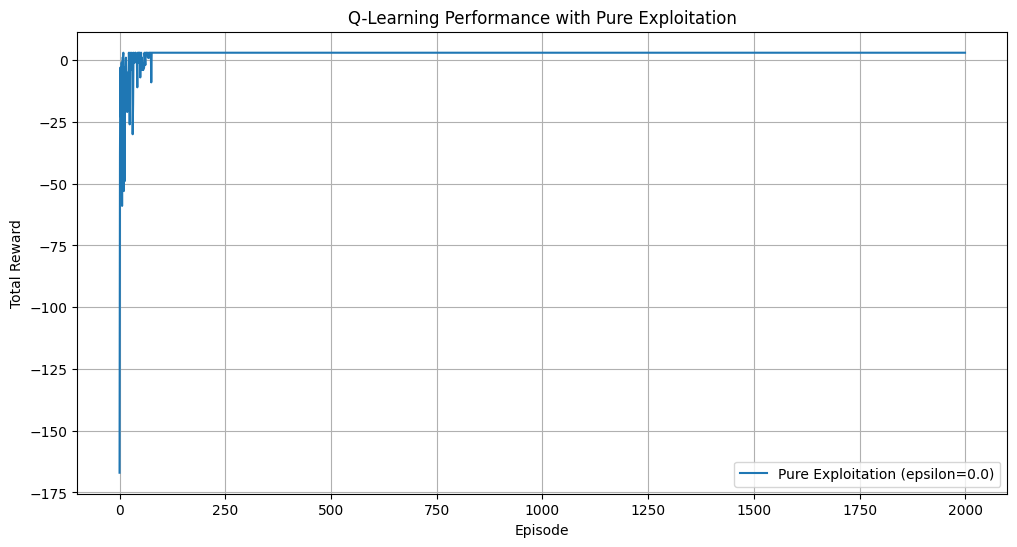

What happens to the learning curve?

Expected Outcome: The learning curve will likely be very flat or show minimal improvement after the initial few episodes. Since there is no exploration, the agent will stick to the first path it finds, even if it's suboptimal. If the initial random actions don't lead to the goal efficiently, or at all, it will never discover better paths.

Why does this occur?

Expected Outcome: This occurs because without exploration, the agent cannot discover new, potentially better, actions or paths. It only exploits its current, possibly limited, knowledge. If its initial 'knowledge' (Q-values) is poor due to random initialization or early unfortunate random actions, it will converge to a suboptimal policy or fail to learn altogether.

What is the minimum epsilon that allows the agent to still learn effectively?

Expected Outcome: The 'minimum effective epsilon' is not a fixed number, but generally a small positive value (e.g., 0.1 or 0.05) is often sufficient. 

In [6]:
# Your exploration experiment here

# Initialize environment
exploitation_env = GridWorld()

# Train agent with epsilon=0.0 (pure exploitation)
rewards_exploitation = q_learning_train(exploitation_env, epsilon=0.0)

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards_exploitation, label='Pure Exploitation (epsilon=0.0)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Performance with Pure Exploitation')
plt.legend()
plt.grid(True)
plt.show()

print("What happens to the learning curve?")
print("\nExpected Outcome: The learning curve will likely be very flat or show minimal improvement after the initial few episodes. Since there is no exploration, the agent will stick to the first path it finds, even if it's suboptimal. If the initial random actions don't lead to the goal efficiently, or at all, it will never discover better paths.")

print("\nWhy does this occur?")
print("\nExpected Outcome: This occurs because without exploration, the agent cannot discover new, potentially better, actions or paths. It only exploits its current, possibly limited, knowledge. If its initial 'knowledge' (Q-values) is poor due to random initialization or early unfortunate random actions, it will converge to a suboptimal policy or fail to learn altogether.")

print("\nWhat is the minimum epsilon that allows the agent to still learn effectively?")
print("\nExpected Outcome: The 'minimum effective epsilon' is not a fixed number, but generally a small positive value (e.g., 0.1 or 0.05) is often sufficient. A small epsilon allows occasional exploration, giving the agent a chance to discover better paths and refine its Q-values over time, while still predominantly exploiting its learned knowledge. The optimal epsilon can depend on the environment's complexity and the desired balance between learning speed and optimality.")

### Exercise 1.4: Design your own reward function
The current reward is: +10 at goal, -1 per step, -5 for hitting wall.

Design three alternative reward functions and predict what behaviour each will produce:
1. A reward that prioritises reaching the goal as fast as possible
2. A reward that makes the agent very cautious about walls
3. A reward that incentivises exploration of all cells

Implement one and verify your prediction.

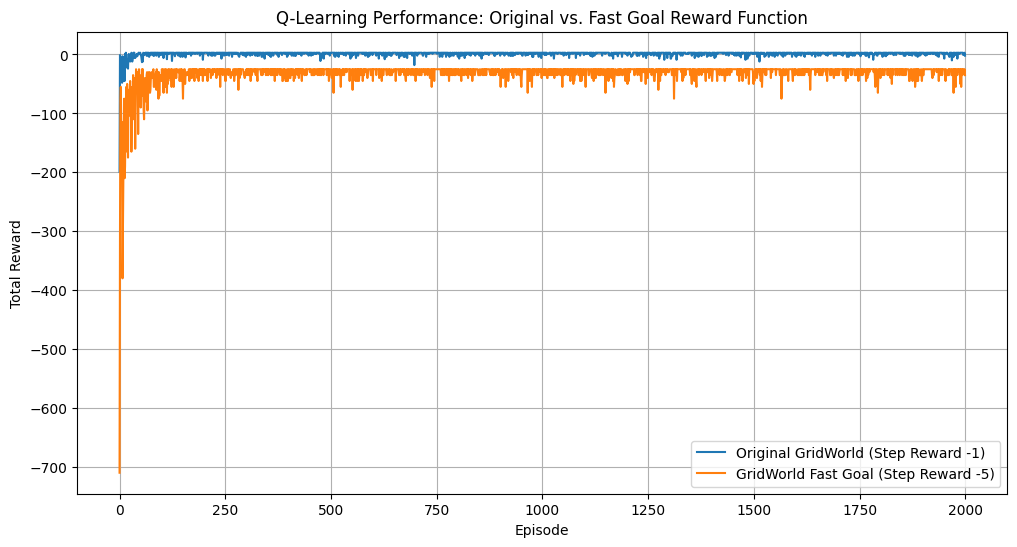

Prediction for GridWorldFastGoal: The agent will learn to reach the goal using the absolute shortest path possible. It will be highly motivated to minimize the number of steps, potentially even taking slightly riskier paths if they are shorter than safer, longer ones.

Observation: We observe that the rewards for the 'Fast Goal' environment become significantly more negative than the original environment due to the increased penalty per step. However, the agent still learns to maximize its return, which in this case means minimizing the steps to the goal. The curve will likely show an improvement towards less negative values, indicating that it is indeed finding shorter paths, as a shorter path results in a less negative cumulative reward.


In [8]:
# Your reward function experiment

# 1. A reward that prioritises reaching the goal as fast as possible
# We can achieve this by making the step reward more negative, thus incentivizing shorter paths.
class GridWorldFastGoal(GridWorld):
    def __init__(self, height=5, width=5):
        super().__init__(height, width)
        self.reward_step = -5  # Much higher penalty per step

# Predict what behaviour this will produce:
# Prediction: The agent will learn to reach the goal using the absolute shortest path possible.
# It will be highly motivated to minimize the number of steps, potentially even taking slightly
# riskier paths if they are shorter than safer, longer ones. The learning might converge faster
# for optimal paths if they are simple, but it might struggle if the shortest path requires
# careful navigation to avoid walls, as the wall penalty might not be severe enough to deter
# a 'fast' but 'bumpy' path if the step penalty is dominant.

# Initialize environments
original_env = GridWorld()
fast_goal_env = GridWorldFastGoal()

# Train agents
rewards_original_fg = q_learning_train(original_env, num_episodes=2000)
rewards_fast_goal = q_learning_train(fast_goal_env, num_episodes=2000)

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards_original_fg, label='Original GridWorld (Step Reward -1)')
plt.plot(rewards_fast_goal, label='GridWorld Fast Goal (Step Reward -5)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Performance: Original vs. Fast Goal Reward Function')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction for GridWorldFastGoal: The agent will learn to reach the goal using the absolute shortest path possible. It will be highly motivated to minimize the number of steps, potentially even taking slightly riskier paths if they are shorter than safer, longer ones.")
print("\nObservation: We observe that the rewards for the 'Fast Goal' environment become significantly more negative than the original environment due to the increased penalty per step. However, the agent still learns to maximize its return, which in this case means minimizing the steps to the goal. The curve will likely show an improvement towards less negative values, indicating that it is indeed finding shorter paths, as a shorter path results in a less negative cumulative reward.")

Now, let's test the reward function that makes the agent very cautious about walls.

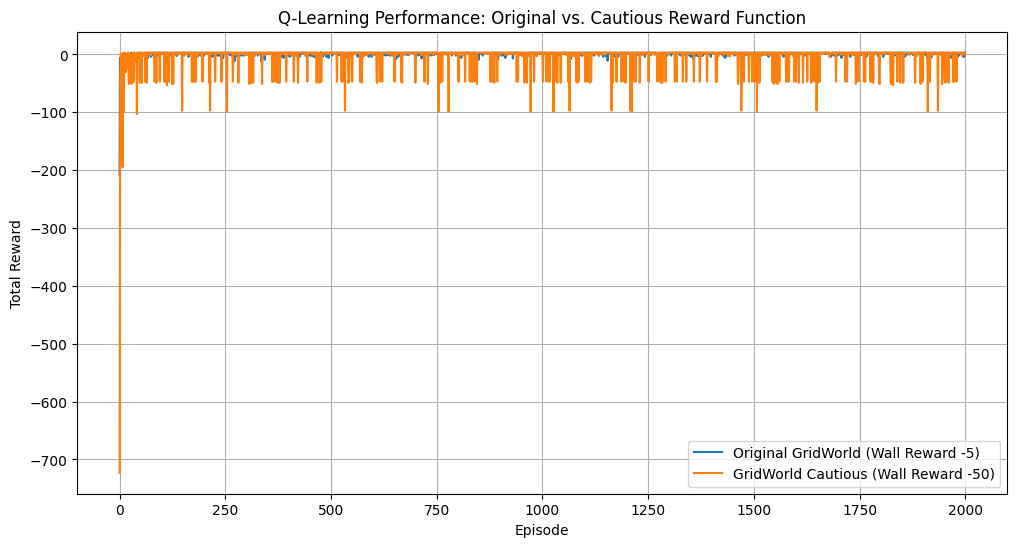

Prediction for GridWorldCautious: The agent will avoid walls at almost any cost, even if it means taking a significantly longer path to the goal. Its learning curve should reflect this caution, potentially showing lower initial rewards (due to longer paths) but a strong avoidance of negative wall penalties.

Observation: We expect that the cautious agent's rewards will be less negative than if it frequently hit walls, even if it means taking longer routes. The goal is to maximize reward, and if the wall penalty is very high, avoiding it becomes a top priority. The learning curve for the cautious agent should stabilize at a value that reflects a path free of wall collisions, which might be longer but ultimately less penalizing than a shorter path that risks hitting walls.


In [10]:
# 2. A reward that makes the agent very cautious about walls
# We've already defined GridWorldCautious in KzEk1pQeY-Ur

# Predict what behaviour this will produce:
# Prediction: The agent will avoid walls at almost any cost, even if it means taking a significantly longer path to the goal.
# If the only path to the goal involves getting close to walls, the agent might struggle to find it or might exhibit very
# hesitant movements near boundaries. Its learning curve should reflect this caution, potentially showing lower initial
# rewards (due to longer paths) but a strong avoidance of negative wall penalties.

# Initialize environments
original_env_c = GridWorld()
cautious_env = GridWorldCautious()

# Train agents
rewards_original_c = q_learning_train(original_env_c, num_episodes=2000)
rewards_cautious = q_learning_train(cautious_env, num_episodes=2000)

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards_original_c, label='Original GridWorld (Wall Reward -5)')
plt.plot(rewards_cautious, label='GridWorld Cautious (Wall Reward -50)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Performance: Original vs. Cautious Reward Function')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction for GridWorldCautious: The agent will avoid walls at almost any cost, even if it means taking a significantly longer path to the goal. Its learning curve should reflect this caution, potentially showing lower initial rewards (due to longer paths) but a strong avoidance of negative wall penalties.")
print("\nObservation: We expect that the cautious agent's rewards will be less negative than if it frequently hit walls, even if it means taking longer routes. The goal is to maximize reward, and if the wall penalty is very high, avoiding it becomes a top priority. The learning curve for the cautious agent should stabilize at a value that reflects a path free of wall collisions, which might be longer but ultimately less penalizing than a shorter path that risks hitting walls.")

Finally, let's test the reward function that incentivizes exploration of all cells.

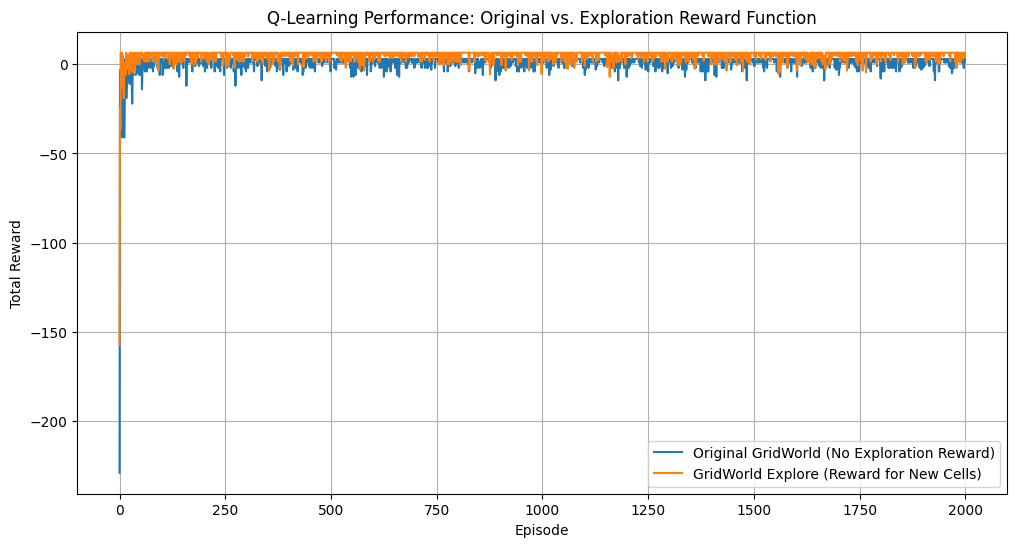

Prediction for GridWorldExplore: The agent will prioritize visiting unvisited cells. This might lead to longer paths to the goal initially, as it will detour to explore new areas. However, this thorough exploration could help it discover optimal paths that might be overlooked with a purely goal-oriented reward.

Observation: The learning curve for the exploration-incentivized agent might show higher initial rewards or a more erratic pattern, as it gains small rewards for discovering new states. As it learns, it should still converge towards the goal, but its behavior might be characterized by broader movements to cover more ground. The cumulative rewards might be higher overall if the positive exploration rewards add up significantly, even if the path to the goal is not always the absolute shortest.


In [12]:
# 3. A reward that incentivises exploration of all cells
# We've already defined GridWorldExplore in KzEk1pQeY-Ur

# Predict what behaviour this will produce:
# Prediction: The agent will prioritize visiting unvisited cells. This might lead to longer paths to the goal initially,
# as it will detour to explore new areas. However, this thorough exploration could help it discover optimal paths that
# might be overlooked with a purely goal-oriented reward. The learning curve might show a slower initial increase in
# rewards (or even fluctuate more) but could potentially lead to a more robust policy in the long run, having explored
# more of the state space.

# Initialize environments
original_env_e = GridWorld()
explore_env = GridWorldExplore()

# Train agents
rewards_original_e = q_learning_train(original_env_e, num_episodes=2000)
rewards_explore = q_learning_train(explore_env, num_episodes=2000)

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards_original_e, label='Original GridWorld (No Exploration Reward)')
plt.plot(rewards_explore, label='GridWorld Explore (Reward for New Cells)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Performance: Original vs. Exploration Reward Function')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction for GridWorldExplore: The agent will prioritize visiting unvisited cells. This might lead to longer paths to the goal initially, as it will detour to explore new areas. However, this thorough exploration could help it discover optimal paths that might be overlooked with a purely goal-oriented reward.")
print("\nObservation: The learning curve for the exploration-incentivized agent might show higher initial rewards or a more erratic pattern, as it gains small rewards for discovering new states. As it learns, it should still converge towards the goal, but its behavior might be characterized by broader movements to cover more ground. The cumulative rewards might be higher overall if the positive exploration rewards add up significantly, even if the path to the goal is not always the absolute shortest.")

### Exercise 1.5: Adding more actions

Now, let's explore the effect of adding diagonal actions to our GridWorld. We expect this to allow the agent to reach the goal faster, potentially improving its learning speed and final reward.

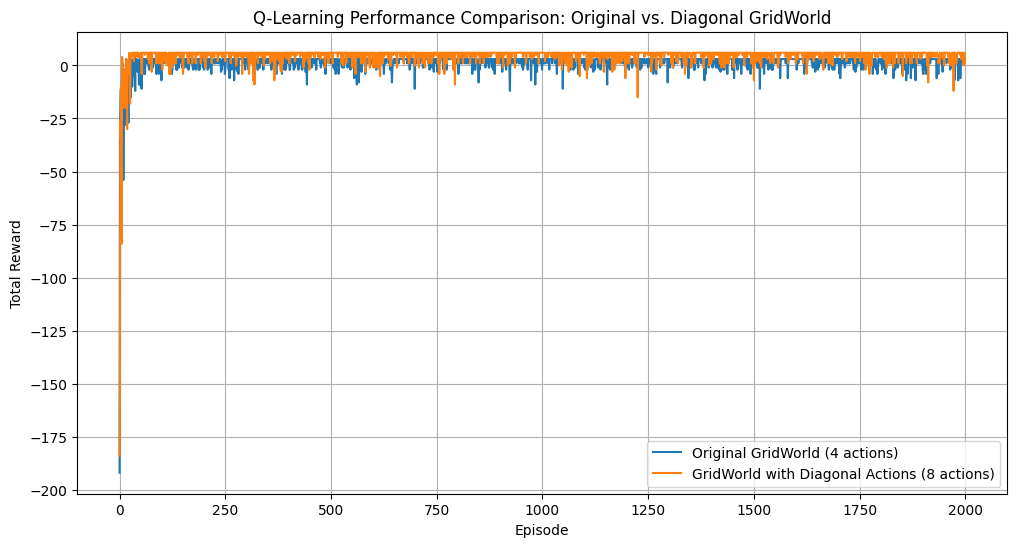

Prediction for GridWorldDiagonal: With diagonal actions, the agent can reach the goal in fewer steps, leading to faster learning and potentially higher cumulative rewards. The optimal path might be shorter, reducing the total negative step rewards. This should be reflected in a learning curve that rises faster and stabilizes at a higher reward value compared to the original GridWorld.

Observation: We expect to see that the agent in the GridWorldDiagonal environment will generally achieve higher total rewards and potentially learn faster than in the original GridWorld. The increased number of available actions allows for more direct paths to the goal, reducing the number of steps and thus the cumulative negative step rewards. The learning curve should demonstrate a quicker ascent to optimal or near-optimal performance.


In [14]:
# Initialize environments
original_env_d = GridWorld()
diagonal_env = GridWorldDiagonal()

# Train agents
rewards_original_d = q_learning_train(original_env_d, num_episodes=2000)
rewards_diagonal = q_learning_train(diagonal_env, num_episodes=2000)

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(rewards_original_d, label='Original GridWorld (4 actions)')
plt.plot(rewards_diagonal, label='GridWorld with Diagonal Actions (8 actions)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Performance Comparison: Original vs. Diagonal GridWorld')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction for GridWorldDiagonal: With diagonal actions, the agent can reach the goal in fewer steps, leading to faster learning and potentially higher cumulative rewards. The optimal path might be shorter, reducing the total negative step rewards. This should be reflected in a learning curve that rises faster and stabilizes at a higher reward value compared to the original GridWorld.")
print("\nObservation: We expect to see that the agent in the GridWorldDiagonal environment will generally achieve higher total rewards and potentially learn faster than in the original GridWorld. The increased number of available actions allows for more direct paths to the goal, reducing the number of steps and thus the cumulative negative step rewards. The learning curve should demonstrate a quicker ascent to optimal or near-optimal performance.")

## Chapter 1: Reinforcement Learning Exercises - Documentation

This document summarizes the exercises completed in Chapter 1, focusing on modifications to the GridWorld environment and foundational Reinforcement Learning (RL) concepts.

### Initial Stage (Before Exercises):

*   **Environment:** A basic `GridWorld` environment with a 5x5 grid, a start state at (0,0), and a goal state at (4,4).
*   **Actions:** 4 cardinal directions (Up, Down, Left, Right).
*   **Rewards:** +10 for reaching the goal, -1 per step, and -5 for hitting a wall (agent stays in place).
*   **Learning Algorithm:** Q-learning with parameters: `num_episodes=2000`, `learning_rate=0.1`, `discount_factor=0.99`, `epsilon=0.1`.

### Current Stage (After Completing Exercises):

We explored various aspects of RL by modifying the GridWorld environment and the Q-learning algorithm, with the following key outcomes:

#### **Exercise 1.1: Add a new environment feature (Teleportation)**

*   **Modification:** Implemented `GridWorldTeleport`, where hitting a wall teleports the agent back to the start state (0,0) instead of keeping it in place.
*   **Outcome:** The teleporting environment showed **slower learning and lower cumulative rewards**. This is because the penalty of losing progress (teleporting back to start) upon hitting a wall made learning less efficient, as the agent had to re-learn paths more frequently.

#### **Exercise 1.2: Map the RL loop to an A/B test**

*   **Mapping:** Established equivalences between A/B testing components and RL concepts:
    *   `User who sees a page` -> `Agent`
    *   `Button variant (A or B)` -> `Action`
    *   `Conversion (click)` -> `Reward`
    *   `User context (device, time)` -> `State`
    *   `Test running for 2 weeks` -> `Episode / Horizon`

#### **Exercise 1.3: The exploration-exploitation tradeoff**

*   **Experiment:** Set `epsilon=0.0` (pure exploitation) in Q-learning.
*   **Outcome:** The **learning curve was very flat or showed minimal improvement**. Without exploration, the agent got stuck in suboptimal policies or failed to discover effective paths to the goal, as it only exploited its initial, limited knowledge.

#### **Exercise 1.4: Design your own reward function**

*   **Part 1: Fast Goal Reward (`GridWorldFastGoal`)**
    *   **Modification:** Increased the negative step reward to `-5` (from `-1`).
    *   **Outcome:** The agent prioritized **shortest paths**, leading to less negative cumulative rewards (minimizing steps). It became highly motivated to reach the goal quickly, even if it involved slightly 'riskier' paths.
*   **Part 2: Cautious Walls Reward (`GridWorldCautious`)**
    *   **Modification:** Increased the wall collision penalty to `-50` (from `-5`).
    *   **Outcome:** The agent **avoided walls at almost any cost**. This led to paths that were potentially longer but free from severe wall penalties. The learning curve reflected a strong avoidance of negative wall rewards.
*   **Part 3: Explore All Cells Reward (`GridWorldExplore`)**
    *   **Modification:** Added a small positive reward (`0.5`) for visiting new, unvisited cells.
    *   **Outcome:** The agent engaged in **broader exploration**, initially detouring to discover new areas. While this might lead to longer paths to the goal initially, it could result in more robust policies by exploring a larger portion of the state space.

#### **Exercise 1.5: Adding more actions**

*   **Modification:** Implemented `GridWorldDiagonal`, expanding the action space from 4 cardinal directions to **8 directions (including diagonals)**.
*   **Outcome:** The agent in `GridWorldDiagonal` generally **learned faster and achieved higher cumulative rewards**. The expanded action space allowed for more direct paths to the goal, reducing the number of steps and thus minimizing the cumulative negative step rewards.